In [1]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
img_size = 224
batch_size = 32

I0000 00:00:1773815665.030536     712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773815665.071993     712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773815665.964623     712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
dataset_path = path

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 7200 files belonging to 2 classes.
Using 5760 files for training.


W0000 00:00:1773815667.310259     712 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1773815667.318521     712 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773815667.437139     712 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5791 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [5]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 7200 files belonging to 2 classes.
Using 1440 files for validation.


In [6]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Testing', 'Training']


In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/home/dhruvgoel/Documents/ml/mlenv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


I0000 00:00:1773815669.753941     993 service.cc:153] XLA service 0x7f0b34004fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773815669.753985     993 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773815669.775764     993 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773815669.954090     993 cuda_dnn.cc:461] Loaded cuDNN version 92000


  4/180 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6042 - loss: 70.8630 

I0000 00:00:1773815674.646636     993 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7575 - loss: 2.9540 - val_accuracy: 0.7924 - val_loss: 0.5189
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7778 - loss: 0.5258 - val_accuracy: 0.7896 - val_loss: 0.5168
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7840 - loss: 0.4915 - val_accuracy: 0.7924 - val_loss: 0.5137
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7875 - loss: 0.4643 - val_accuracy: 0.7840 - val_loss: 0.5264
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.7995 - loss: 0.4422 - val_accuracy: 0.7771 - val_loss: 0.5390
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8090 - loss: 0.4175 - val_accuracy: 0.7660 - val_loss: 0.6129
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8260 - loss: 0.3889 - val_accuracy: 0.7667 - val_loss: 0.6243
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8523 - loss: 0.3351 - val_accuracy: 0.73

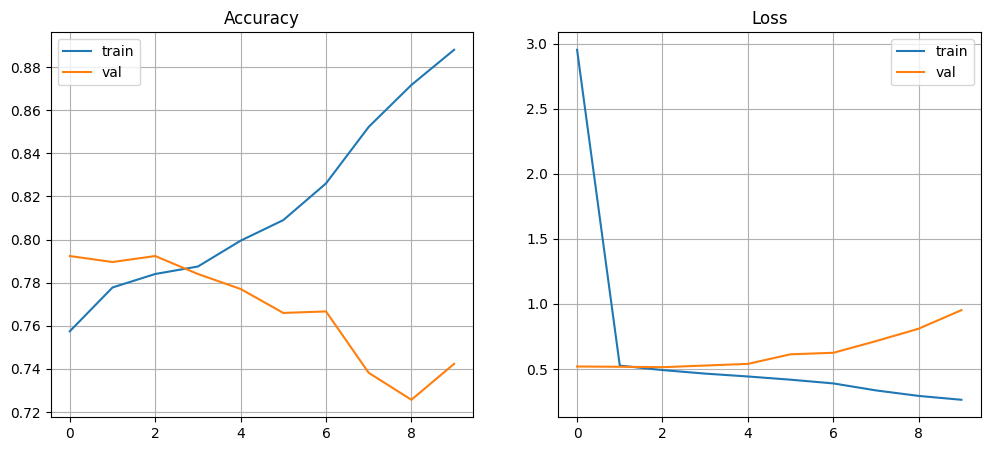

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7424 - loss: 0.9524
Loss: 0.9524, Accuracy: 74.23611283%


In [9]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.legend()
ax1.grid()
ax1.set_title("Accuracy")
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.legend()
ax2.grid()
ax2.set_title("Loss")
plt.show()
loss , accu = model.evaluate(val_ds, batch_size=batch_size)
print(f"Loss: {loss:.4f}, Accuracy: {accu*100:.8f}%")